# Proyecto Telecomunicaciones: identificar operadores ineficaces

El servicio de telefonía virtual CallMeMaybe está desarrollando una nueva función que brindará a los supervisores y las supervisores información sobre los operadores menos eficaces. Se considera que un operador es ineficaz si tiene una gran cantidad de llamadas entrantes perdidas (internas y externas) y un tiempo de espera prolongado para las llamadas entrantes. Además, si se supone que un operador debe realizar llamadas salientes, un número reducido de ellas también será un signo de ineficacia.  
Los datasets contienen información sobre el uso del servicio de telefonía virtual CallMeMaybe. Sus clientes son organizaciones que necesitan distribuir gran cantidad de llamadas entrantes entre varios operadores, o realizar llamadas salientes a través de sus operadores. Los operadores también pueden realizar llamadas internas para comunicarse entre ellos. Estas llamadas se realizan a través de la red de CallMeMaybe.  

El dataset comprimido `telecom_dataset_us.csv` contiene las siguientes columnas:  
  
- `user_id`: ID de la cuenta de cliente  
- `date`: fecha en la que se recuperaron las estadísticas  
- `direction`: "dirección" de llamada (`out` para saliente, `in` para entrante)  
- `internal`: si la llamada fue interna (entre los operadores de un cliente o clienta)  
- `operator_id`: identificador del operador  
- `is_missed_call`: si fue una llamada perdida  
- `calls_count`: número de llamadas  
- `call_duration`: duración de la llamada (sin incluir el tiempo de espera)  
- `total_call_duration`: duración de la llamada (incluido el tiempo de espera)  
  
El conjunto de datos `telecom_clients_us.csv` tiene las siguientes columnas:  

- `user_id`: ID de usuario/a  
- `tariff_plan`: tarifa actual de la clientela  
- `date_start`: fecha de registro de la clientela  


In [99]:
%pip install matplotlib 
%pip install seaborn
%pip install plotly.express

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# 1.IMPORTAR LIBRERIAS Y ACCEDER A LOS DATOS


In [100]:
import pandas as pd
import numpy as np
import seaborn as sns
import math as mt
from matplotlib import pyplot as plt
from scipy import stats as st
from sqlalchemy import create_engine

In [101]:
df_tdu = pd.read_csv('c:/Users/PC/Proyecto_Telecomunicaciones_identificar_operadores_ineficaces/telecom_dataset_new.csv')
df_tcu = pd.read_csv('c:/Users/PC/Proyecto_Telecomunicaciones_identificar_operadores_ineficaces/telecom_clients.csv')

# 2.EXPLORACION Y PROCESAMIENTO DE DATOS

## Dataset telecom (df_tdu)

In [102]:
df_tdu.info(show_counts=True)
print()
print(df_tdu.columns)
print()
print('Hay tantas(filas y columnas)=', df_tdu.shape)
print()
df_tdu

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB

Index(['user_id', 'date', 'direction', 'internal', 'operator_id',
       'is_missed_call', 'calls_count', 'call_duration',
       'total_call_duration'],
      dtype='object')

Hay tantas(filas y columnas)= (53902, 9)



,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25
...,...,...,...,...,...,...,...,...,...
53897,168606,2019-11-10 00:00:00+03:00,out,True,957922.0,True,1,0,38
53898,168606,2019-11-11 00:00:00+03:00,out,True,957922.0,False,2,479,501
53899,168606,2019-11-15 00:00:00+03:00,out,True,957922.0,False,4,3130,3190
53900,168606,2019-11-15 00:00:00+03:00,out,True,957922.0,False,4,3130,3190


Este es el primer dataset que nos proporciona la empresa y en un vistazo rápido se observa que los nombres de las columnas estan uniformes todos en minúsculas y con sanke case.    
    
Pero vemos que la columna "operaotr_id" tiene valores nulos y además estan como números flotantes; así como la columna "date" esta como object enlugar de date.


In [103]:
df_tdu['operator_id'] = df_tdu['operator_id'].round().astype('Int64')
df_tdu['date'] = pd.to_datetime(df_tdu['date']).dt.tz_localize(None)
print(df_tdu.info(show_counts=True))
print()
df_tdu

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   user_id              53902 non-null  int64         
 1   date                 53902 non-null  datetime64[ns]
 2   direction            53902 non-null  object        
 3   internal             53785 non-null  object        
 4   operator_id          45730 non-null  Int64         
 5   is_missed_call       53902 non-null  bool          
 6   calls_count          53902 non-null  int64         
 7   call_duration        53902 non-null  int64         
 8   total_call_duration  53902 non-null  int64         
dtypes: Int64(1), bool(1), datetime64[ns](1), int64(4), object(2)
memory usage: 3.4+ MB
None



,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04,in,False,<NA>,True,2,0,4
1,166377,2019-08-05,out,True,880022,True,3,0,5
2,166377,2019-08-05,out,True,880020,True,1,0,1
3,166377,2019-08-05,out,True,880020,False,1,10,18
4,166377,2019-08-05,out,False,880022,True,3,0,25
...,...,...,...,...,...,...,...,...,...
53897,168606,2019-11-10,out,True,957922,True,1,0,38
53898,168606,2019-11-11,out,True,957922,False,2,479,501
53899,168606,2019-11-15,out,True,957922,False,4,3130,3190
53900,168606,2019-11-15,out,True,957922,False,4,3130,3190


Por ahora hemos cambiado los valores de al columna "date" a tipo datetime y quitamos la zona horaria ya que si necesitamos algún cálculo con estos valores es mas sencillo y también se han modificado los valores tipo float de la columna "operator_id" pero respetando los valores nulos que encontramos en dataframe ya que aún la exploración de datos no ha concluido y además la diferencia entre 53903 del total de datos de entrada contra 45730 datos no nulos de al columna representa un poco mas del 15% de valores de valores nulos por lo que simplemente eliminar dichas filas no seria una opción ya que el sesgo del análisis podría afectar. La columna is_missed_call esta compuesta por valores booleanos.

## Dataset clients (df_tcu)

In [104]:
df_tcu.info(show_counts=True)
print()
print(df_tcu.columns)
print()
print('Hay tantas(filas y columnas)=', df_tcu.shape)
print()
df_tcu

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB

Index(['user_id', 'tariff_plan', 'date_start'], dtype='object')

Hay tantas(filas y columnas)= (732, 3)



,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16
...,...,...,...
727,166554,B,2019-08-08
728,166911,B,2019-08-23
729,167012,B,2019-08-28
730,166867,B,2019-08-22


En este segundo dataset con 3 columnas observamos que al igual que el anterior todas están en minúsculas y con snake case, pero los valores de "date_start" están como object lo ideal seria cambiarlos a tipo date, que es lo que ya hicimos en el datset anterior

In [105]:
df_tcu['date_start'] = pd.to_datetime(df_tcu['date_start'], format='%Y-%m-%d', errors='coerce')
print(df_tcu.info(show_counts=True))
print()
df_tcu

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   user_id      732 non-null    int64         
 1   tariff_plan  732 non-null    object        
 2   date_start   732 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 17.3+ KB
None



,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16
...,...,...,...
727,166554,B,2019-08-08
728,166911,B,2019-08-23
729,167012,B,2019-08-28
730,166867,B,2019-08-22


## Duplicados y valores nulos (df_tdu)

In [106]:
print('Hay ', df_tdu.duplicated().sum(), 'filas completas duplicadas')
print()
print('Hay', df_tdu.duplicated(subset=['user_id', 'date', 'operator_id']).sum(), 'usuarios duplicados, fechas y operadores en el mismo renglon')
display(df_tdu[df_tdu.duplicated(keep=False)])

Hay  4900 filas completas duplicadas

Hay 27256 usuarios duplicados, fechas y operadores en el mismo renglon


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
6,166377,2019-08-05,out,False,880020,True,8,0,50
8,166377,2019-08-05,out,False,880020,True,8,0,50
27,166377,2019-08-12,in,False,<NA>,True,2,0,34
28,166377,2019-08-12,in,False,<NA>,True,2,0,34
38,166377,2019-08-14,in,False,<NA>,True,1,0,3
...,...,...,...,...,...,...,...,...,...
53875,168601,2019-11-26,in,False,<NA>,True,3,0,35
53883,168603,2019-11-20,out,False,959118,True,3,0,89
53885,168603,2019-11-20,out,False,959118,True,3,0,89
53899,168606,2019-11-15,out,True,957922,False,4,3130,3190


Tenemos 4900 filas completas duplicadas; cuando tenemos filas completas duplicadas, si que nuestro análisis puede verse afectado ya que tener valores duplicados pues sesga lso resultados, por lo que aquí lo adecuado sería eliminar esas  filas, además de que 4900 filas son mas del 9% de las filas del dataset lo cual es demasiado  y sin duda tendra impacto en los resultados.

In [107]:
df_tdu = df_tdu.drop_duplicates()
print('Ahora hay ', df_tdu.duplicated().sum(), 'filas completas duplicadas' )
print()
df_tdu.info()
display(df_tdu)

Ahora hay  0 filas completas duplicadas

<class 'pandas.core.frame.DataFrame'>
Index: 49002 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   user_id              49002 non-null  int64         
 1   date                 49002 non-null  datetime64[ns]
 2   direction            49002 non-null  object        
 3   internal             48892 non-null  object        
 4   operator_id          41546 non-null  Int64         
 5   is_missed_call       49002 non-null  bool          
 6   calls_count          49002 non-null  int64         
 7   call_duration        49002 non-null  int64         
 8   total_call_duration  49002 non-null  int64         
dtypes: Int64(1), bool(1), datetime64[ns](1), int64(4), object(2)
memory usage: 3.5+ MB


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04,in,False,<NA>,True,2,0,4
1,166377,2019-08-05,out,True,880022,True,3,0,5
2,166377,2019-08-05,out,True,880020,True,1,0,1
3,166377,2019-08-05,out,True,880020,False,1,10,18
4,166377,2019-08-05,out,False,880022,True,3,0,25
...,...,...,...,...,...,...,...,...,...
53896,168606,2019-11-10,out,True,957922,False,1,0,25
53897,168606,2019-11-10,out,True,957922,True,1,0,38
53898,168606,2019-11-11,out,True,957922,False,2,479,501
53899,168606,2019-11-15,out,True,957922,False,4,3130,3190


In [108]:
df_missed_call_true = df_tdu[df_tdu['is_missed_call'] == True]
display(df_missed_call_true)
print('Valor de call_duration diferente de 0 = ', len(df_missed_call_true[df_missed_call_true['call_duration'] != 0]))

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04,in,False,<NA>,True,2,0,4
1,166377,2019-08-05,out,True,880022,True,3,0,5
2,166377,2019-08-05,out,True,880020,True,1,0,1
4,166377,2019-08-05,out,False,880022,True,3,0,25
6,166377,2019-08-05,out,False,880020,True,8,0,50
...,...,...,...,...,...,...,...,...,...
53890,168606,2019-11-08,out,False,957922,True,2,0,40
53891,168606,2019-11-08,in,False,957922,True,1,0,7
53893,168606,2019-11-08,in,False,<NA>,True,6,0,121
53897,168606,2019-11-10,out,True,957922,True,1,0,38


Valor de call_duration diferente de 0 =  296


In [109]:
df_missed_call_true.isna().sum()

user_id                   0
date                      0
direction                 0
internal                 56
operator_id            7343
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64

In [110]:
df_missed_call_false = df_tdu[df_tdu['is_missed_call'] == False]
df_missed_call_false

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
3,166377,2019-08-05,out,True,880020,False,1,10,18
5,166377,2019-08-05,out,False,880020,False,2,3,29
13,166377,2019-08-06,out,False,880020,False,5,800,819
15,166377,2019-08-07,out,False,880026,False,1,21,28
16,166377,2019-08-07,out,False,880020,False,2,232,240
...,...,...,...,...,...,...,...,...,...
53894,168606,2019-11-08,in,False,957922,False,2,686,705
53895,168606,2019-11-09,out,False,957922,False,4,551,593
53896,168606,2019-11-10,out,True,957922,False,1,0,25
53898,168606,2019-11-11,out,True,957922,False,2,479,501


In [111]:
df_missed_call_false.isna().sum()

user_id                  0
date                     0
direction                0
internal                54
operator_id            113
is_missed_call           0
calls_count              0
call_duration            0
total_call_duration      0
dtype: int64

Indagando acerca de lso vlaores nulos encontrados si filtramos el dataset por la columna is_missed_call por las llamadas pediidas(True) observamso un total de 7343 del total 7456, lo cual hace sentido ya que las llmadas perdidas nunca afueron asignadas a un operador el resto de 113  valore nulos para operadores estan con el registro de True es un porcentaje muy pequeño tanto en el total de los valores snulos como el total de la columna entera y además no tenemso información para saber porque se presento esta situación.

In [112]:
df_tdu = df_tdu.copy()
df_tdu['operator_id'] = df_tdu['operator_id'].astype(str).replace('<NA>', 'unknown')
print(df_tdu['operator_id'].dtype)
print()
display(df_tdu)

object



,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04,in,False,unknown,True,2,0,4
1,166377,2019-08-05,out,True,880022,True,3,0,5
2,166377,2019-08-05,out,True,880020,True,1,0,1
3,166377,2019-08-05,out,True,880020,False,1,10,18
4,166377,2019-08-05,out,False,880022,True,3,0,25
...,...,...,...,...,...,...,...,...,...
53896,168606,2019-11-10,out,True,957922,False,1,0,25
53897,168606,2019-11-10,out,True,957922,True,1,0,38
53898,168606,2019-11-11,out,True,957922,False,2,479,501
53899,168606,2019-11-15,out,True,957922,False,4,3130,3190


Lo que realizamos en este paso fue cambiar la columna de operator_id de int a object y los valores nulos que ahora son object también reemplazarlos por unknown ya que solo elimnarlos no es opción ya que aunque podriamos hacerlo porque estamos buscando por usuario si es efciaz o no el computo total como algún pormedio o mediana o seviación si que s epuden ver modificados.

In [113]:
df_tdu.isna().sum()

user_id                  0
date                     0
direction                0
internal               110
operator_id              0
is_missed_call           0
calls_count              0
call_duration            0
total_call_duration      0
dtype: int64

In [114]:
df_tdu_unknown_operators = df_tdu[df_tdu['operator_id'] == 'unknown']
df_tdu_unknown_operators

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04,in,False,unknown,True,2,0,4
7,166377,2019-08-05,in,False,unknown,True,6,0,35
9,166377,2019-08-06,in,False,unknown,True,4,0,62
17,166377,2019-08-07,in,False,unknown,True,2,0,24
27,166377,2019-08-12,in,False,unknown,True,2,0,34
...,...,...,...,...,...,...,...,...,...
53876,168601,2019-11-27,in,False,unknown,True,2,0,39
53880,168601,2019-11-28,in,False,unknown,True,1,0,19
53889,168603,2019-11-28,in,False,unknown,True,1,0,30
53893,168606,2019-11-08,in,False,unknown,True,6,0,121


In [115]:
null_index = df_tdu[df_tdu['internal'].isna()].index
half= len(null_index) // 2
index_in = null_index[:half]
index_out = null_index[half:]
df_tdu.loc[index_in, 'internal'] = 'True'
df_tdu.loc[index_out, 'internal'] = 'False'
df_tdu.isna().sum()

user_id                0
date                   0
direction              0
internal               0
operator_id            0
is_missed_call         0
calls_count            0
call_duration          0
total_call_duration    0
dtype: int64

Con la finalidad de terminar de limpiar, ordenar y procesar el dataset df_tdu en los pasos anteriores eliminamos aquellas filas completas  duplicadas ya que eran 4900 filas de 53,902 lo cual es más d eun 9% y podría afecta o sesgar el análisis, despúes nos ocupamos de los vlaores nulos donde en al columna operator_id aparecen un total de 7,456 lo cual también es un porcentaje alto del total de entradas en el dataset pero casi todos estan realcionados con el valor True de la columna is_missed_call lo cual nos indica que son llamdas perdidas y por lo tanto es entendible que no tengan un operador asigando y lo cconfirmamos conla función len() en al columna call_duration debe tener en su mayoría valor 0; pero a diferencia de los valores duplicados no lso leimanmos sino que los rellenamos con la palabra unknown. Por último los valores nulos de la columna internal  encontramos solo 110 valores que este si e sporcentaje pequeño apeans del 0.22% por lo que se podrían eliminar esas filas o también añadir 55 y 55 a true y false que fue lo que se realizó ya que 110 valores e sunh porcentaje no llega ni al 0.5% del dataset.

## Duplicados y valores nulos (df_tcu)

In [116]:
print('Hay ', df_tcu.duplicated().sum(), 'filas completas duplicadas')
print()
print('Hay', df_tcu.duplicated(subset=['user_id']).sum(), 'usuarios duplicados')

Hay  0 filas completas duplicadas

Hay 0 usuarios duplicados


In [117]:
df_tcu.isna().sum()

user_id        0
tariff_plan    0
date_start     0
dtype: int64

In [118]:
print('Estos son los tipos de tarifa:', df_tcu['tariff_plan'].unique())

Estos son los tipos de tarifa: ['A' 'C' 'B']


# 3 ANALISIS EXPLORATORIO DE DATOS (EDA)

Acontinuación hemos añadido aun acolumna a al datset df_tdu waiting_time_call que es la diferencia de la duracion total de la llamada menos la duracion y así obtenemos el tiempo de espera.

In [119]:
df_tdu['waiting_time_call'] = df_tdu['total_call_duration'] - df_tdu['call_duration']
df_tdu

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,waiting_time_call
0,166377,2019-08-04,in,False,unknown,True,2,0,4,4
1,166377,2019-08-05,out,True,880022,True,3,0,5,5
2,166377,2019-08-05,out,True,880020,True,1,0,1,1
3,166377,2019-08-05,out,True,880020,False,1,10,18,8
4,166377,2019-08-05,out,False,880022,True,3,0,25,25
...,...,...,...,...,...,...,...,...,...,...
53896,168606,2019-11-10,out,True,957922,False,1,0,25,25
53897,168606,2019-11-10,out,True,957922,True,1,0,38,38
53898,168606,2019-11-11,out,True,957922,False,2,479,501,22
53899,168606,2019-11-15,out,True,957922,False,4,3130,3190,60


In [120]:
df_tac_merged = df_tdu.merge(df_tcu, on='user_id')
df_tac_merged

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,waiting_time_call,tariff_plan,date_start
0,166377,2019-08-04,in,False,unknown,True,2,0,4,4,B,2019-08-01
1,166377,2019-08-05,out,True,880022,True,3,0,5,5,B,2019-08-01
2,166377,2019-08-05,out,True,880020,True,1,0,1,1,B,2019-08-01
3,166377,2019-08-05,out,True,880020,False,1,10,18,8,B,2019-08-01
4,166377,2019-08-05,out,False,880022,True,3,0,25,25,B,2019-08-01
...,...,...,...,...,...,...,...,...,...,...,...,...
48997,168606,2019-11-10,out,True,957922,False,1,0,25,25,C,2019-10-31
48998,168606,2019-11-10,out,True,957922,True,1,0,38,38,C,2019-10-31
48999,168606,2019-11-11,out,True,957922,False,2,479,501,22,C,2019-10-31
49000,168606,2019-11-15,out,True,957922,False,4,3130,3190,60,C,2019-10-31


Ahora hemos creado un dataset combinando mabos datasets para tene un solo concnentrado de información el cual llamamaos: 
    
df_tac_merged = df_tdu y df_tcu(combinados con al función merge por medio de la columna user_id)

In [121]:
df_tac_merged[['calls_count', 'call_duration', 'total_call_duration', 'waiting_time_call']].describe()

,calls_count,call_duration,total_call_duration,waiting_time_call
count,49002.000000,49002.000000,49002.000000,49002.000000
mean,16.462777,866.282091,1156.558202,290.276111
std,63.604098,3775.503352,4451.473661,1132.155291
min,1.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,46.000000,17.000000
50%,4.000000,37.000000,208.000000,55.000000
75%,12.000000,570.000000,901.000000,200.000000
max,4817.000000,144395.000000,166155.000000,46474.000000


In [122]:
df_tac_merged[['date', 'date_start']].describe()

,date,date_start
count,49002,49002
mean,2019-10-23 00:59:11.071384832,2019-09-09 00:24:35.792824576
min,2019-08-02 00:00:00,2019-08-01 00:00:00
25%,2019-10-04 00:00:00,2019-08-19 00:00:00
50%,2019-10-28 00:00:00,2019-09-04 00:00:00
75%,2019-11-14 00:00:00,2019-10-01 00:00:00
max,2019-11-28 00:00:00,2019-10-31 00:00:00


,date_day,user_id
0,1,1413
1,2,1012
2,3,999
3,4,1077
4,5,1443
5,6,1334
6,7,1580
7,8,1567
8,9,1252
9,10,1236



El promedio de llmadas por día es: 1580.71


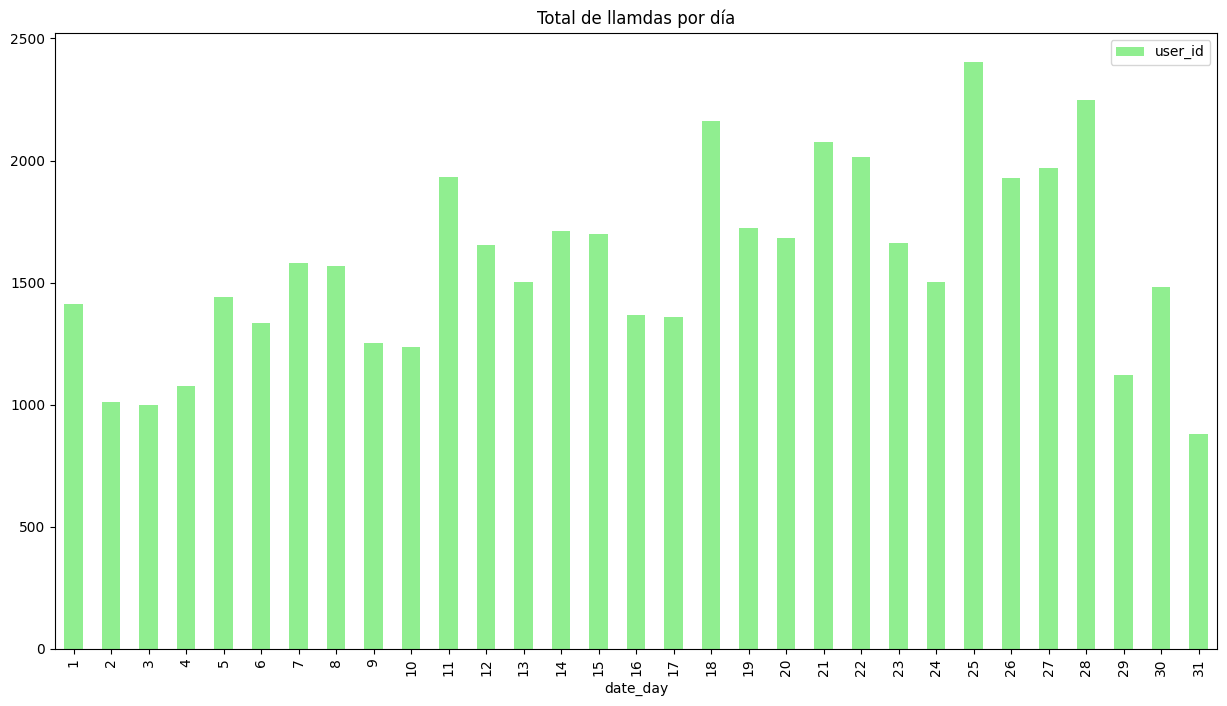

In [123]:
df_tac_merged['date_day'] = df_tac_merged['date'].dt.day
df_calls_per_day = df_tac_merged.groupby('date_day')['user_id'].count().reset_index()
display(df_calls_per_day)
df_calls_per_day.plot(figsize=[15, 8], x='date_day', kind='bar', title='Total de llamdas por día', color='lightgreen')
print()
print('El promedio de llmadas por día es:', df_calls_per_day['user_id'].mean().round(2))


 Antes de comenzar con al busqueda d elso operarios eficaces e ineficaces ahermos alguans observaciones generales como este gráfico donde vemos el total de llmadas por día del mes con un promedio de llamadas de 1580 por días y observamos que hacia lso últimos días del mes hay una alza de llamadas entre lso días 18 y 26 del mes.

direction,in,out
date_day,,
1,5735,18814
2,4524,15680
3,4574,16532
4,4915,16173
5,6608,18010
6,5855,16276
7,8666,21218
8,7405,21533
9,5514,18546


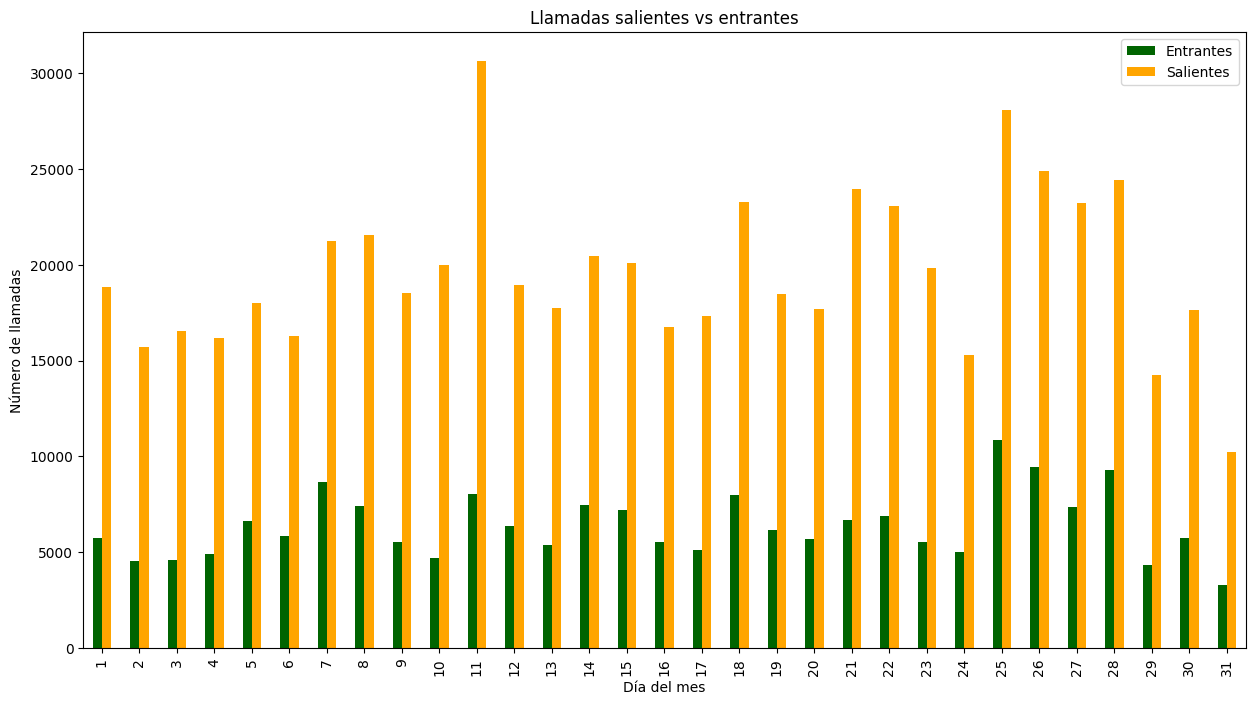

In [124]:
df_calls_per_direction = df_tac_merged.groupby(['date_day', 'direction'])['calls_count'].sum().unstack()
display(df_calls_per_direction)
df_calls_per_direction.plot(figsize=[15, 8],  kind='bar', title='Llamadas salientes vs entrantes', color=['darkgreen', 'orange'])
plt.xlabel('Día del mes')
plt.ylabel('Número de llamadas')
plt.legend(['Entrantes', 'Salientes'])
plt.show()

ESte gráfico tiene la intenbción de visualizar al relación entre las llamdas que entran y salen claramente hay mas salidas.

direction,in,out
date,,
2019-08-02,2.0,19.0
2019-08-03,3.0,26.0
2019-08-04,2.0,4.0
2019-08-05,12.0,180.0
2019-08-06,52.0,177.0
...,...,...
2019-11-24,1323.0,2776.0
2019-11-25,6646.0,10856.0
2019-11-26,6012.0,10530.0


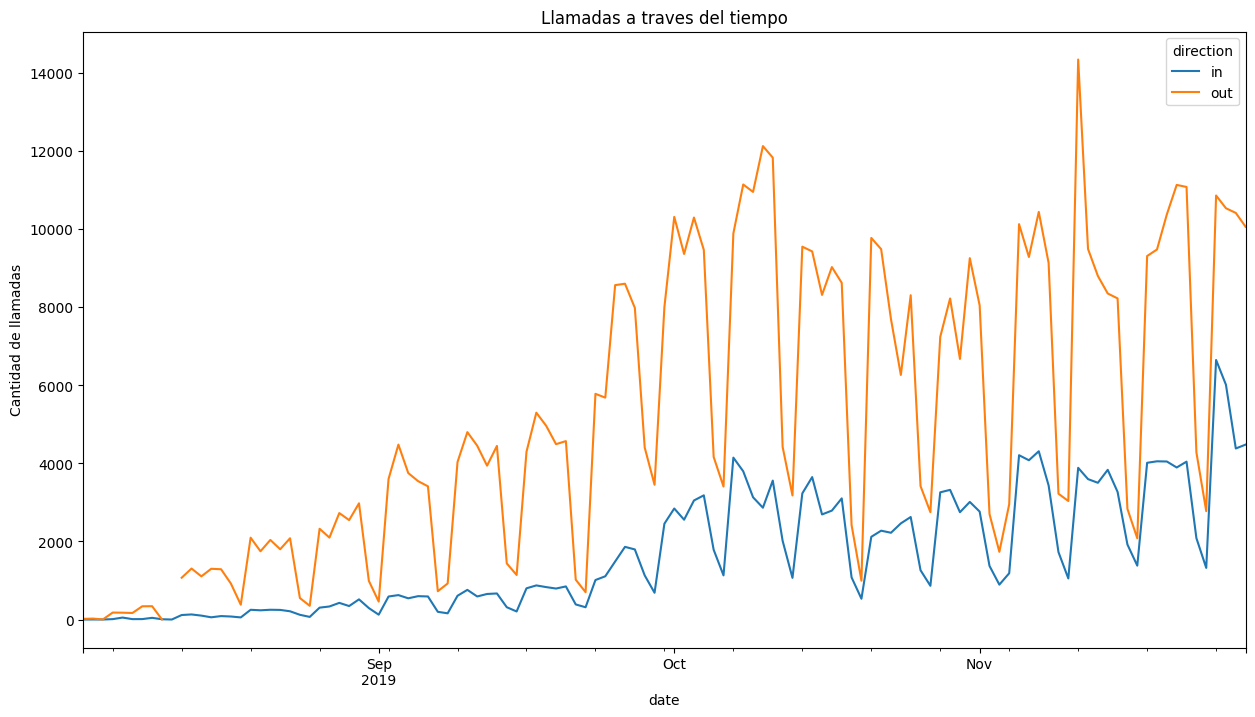

In [125]:
df_calls_date = df_tac_merged.groupby(['date', 'direction'])['calls_count'].sum().unstack()
display(df_calls_date)
df_calls_date.plot(figsize=(15,8), title= 'Llamadas a traves del tiempo')
plt.ylabel('Cantidad de llamadas')
plt.show()

In [126]:
df_external_calls = df_tac_merged[df_tac_merged['internal']== False]
calls_direction = df_external_calls['direction'].value_counts()
direction_percentage = df_external_calls['direction'].value_counts(normalize=True) * 100
print('Llamadas:')
print(calls_direction)
print('\nPorcentaje Total:')
print(direction_percentage.round(2))

Llamadas:
direction
out    24015
in     19224
Name: count, dtype: int64

Porcentaje Total:
direction
out    55.54
in     44.46
Name: proportion, dtype: float64


Las llamadas internas contra externas vemos que hay mas de un 55% para las externas 

,tariff_plan,user_id
0,A,13556
1,B,17237
2,C,18209


<Axes: title={'center': 'Usuarios por tarifa'}, xlabel='tariff_plan'>

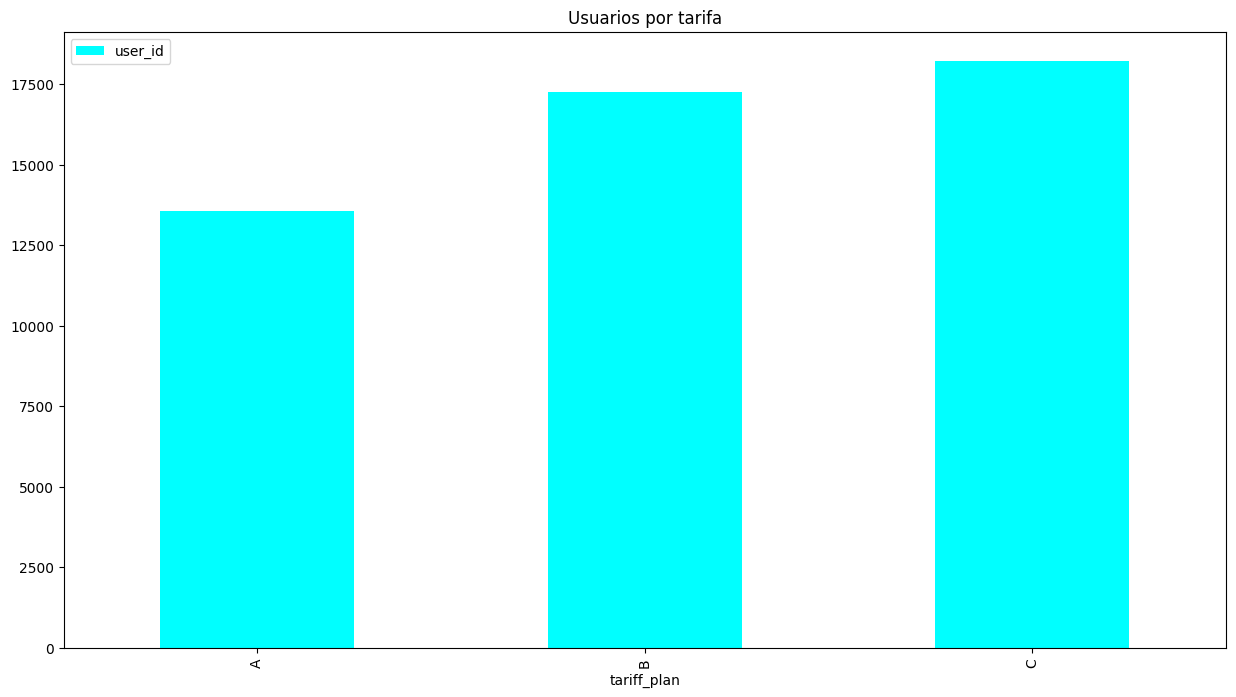

In [127]:
df_per_tariff = df_tac_merged.groupby('tariff_plan')['user_id'].count().reset_index()
display(df_per_tariff)
df_per_tariff.plot(figsize=[15, 8], x='tariff_plan', kind='bar', title='Usuarios por tarifa', color='cyan')

Un pequeño gráfico que simplemnete nos ayuda a comrpender del total de usuariso como se dividen entre los ti´pos de tarifas que maneja la compañía

<Axes: title={'center': 'Número de llamadas'}, ylabel='calls_count'>

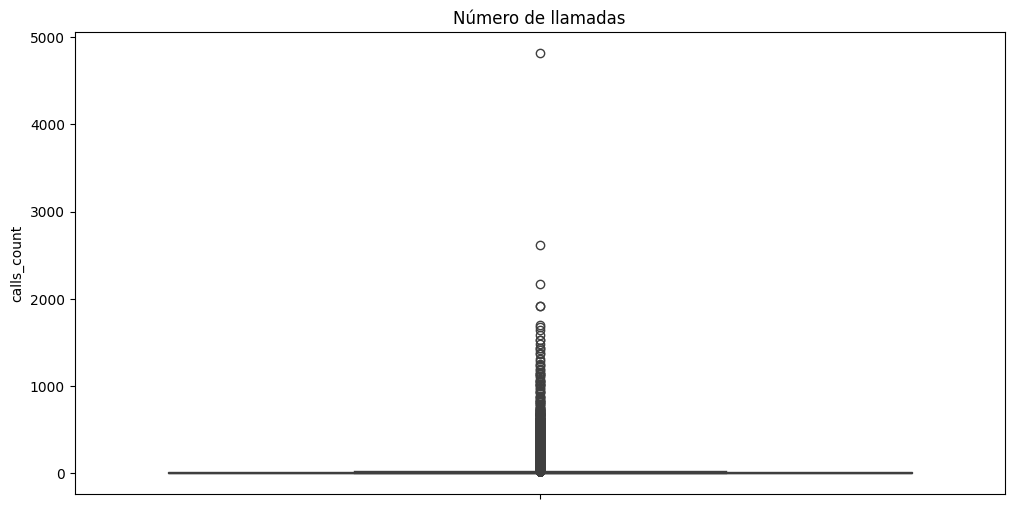

In [128]:
plt.figure(figsize=(12, 6))
plt.title('Número de llamadas')
sns.boxplot(y=df_tac_merged['calls_count'])


<Axes: title={'center': 'Número de llamadas'}, ylabel='calls_count'>

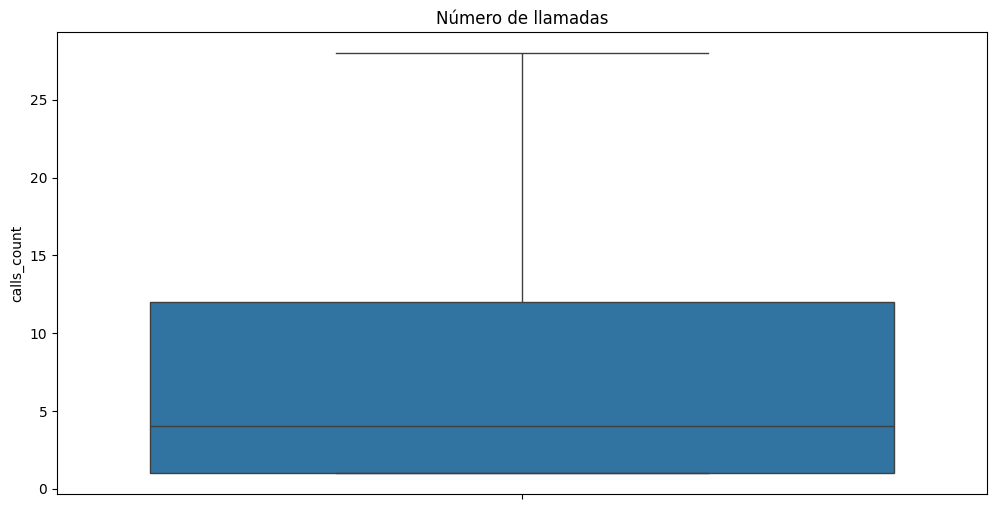

In [129]:
plt.figure(figsize=(12, 6))
plt.title('Número de llamadas')
sns.boxplot(y=df_tac_merged['calls_count'], showfliers=False)

<Axes: title={'center': 'Duración de llamadas'}, ylabel='call_duration'>

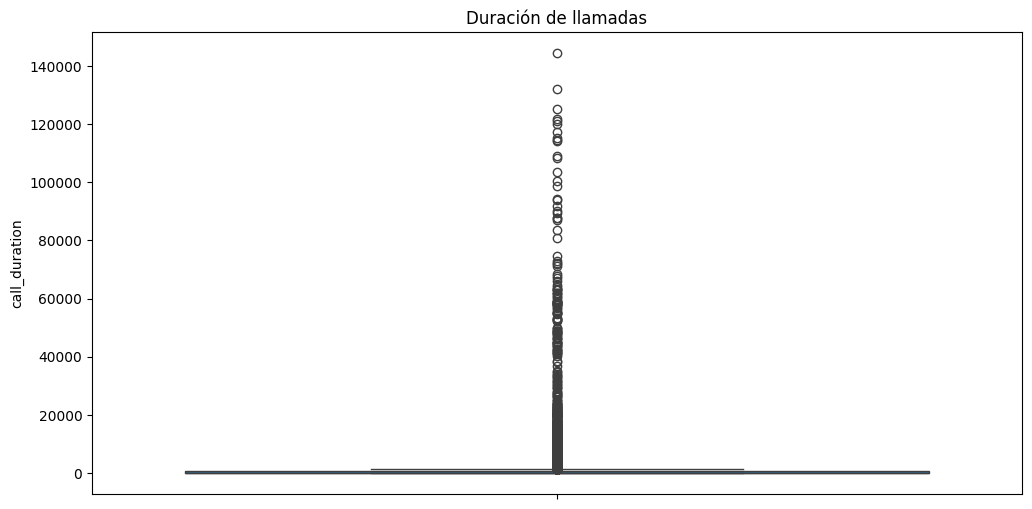

In [130]:
plt.figure(figsize=(12, 6))
plt.title('Duración de llamadas')
sns.boxplot(y=df_tac_merged['call_duration'])

<Axes: title={'center': 'Duración de llamadas'}, ylabel='call_duration'>

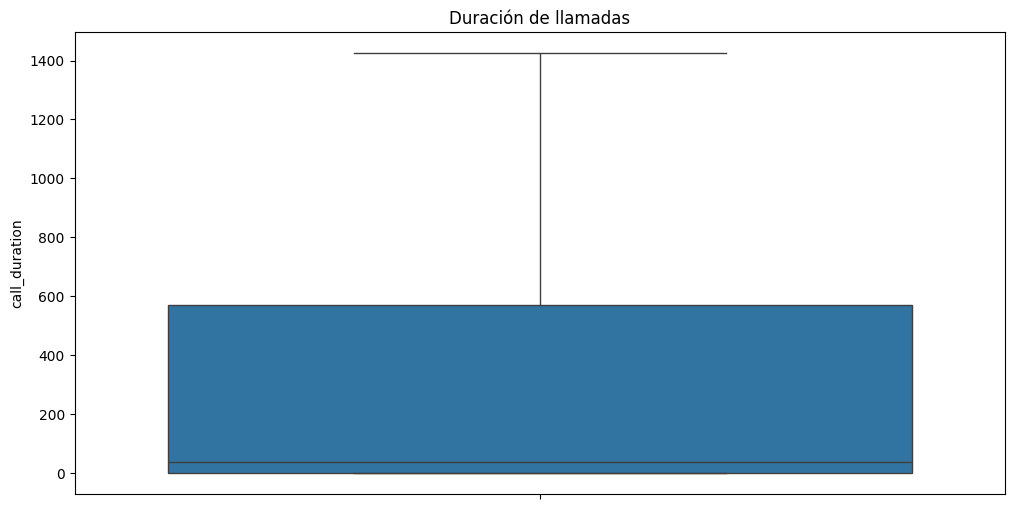

In [131]:
plt.figure(figsize=(12, 6))
plt.title('Duración de llamadas')
sns.boxplot(y=df_tac_merged['call_duration'], showfliers=False)

<Axes: title={'center': 'Tiempo de espera de llamadas'}, ylabel='waiting_time_call'>

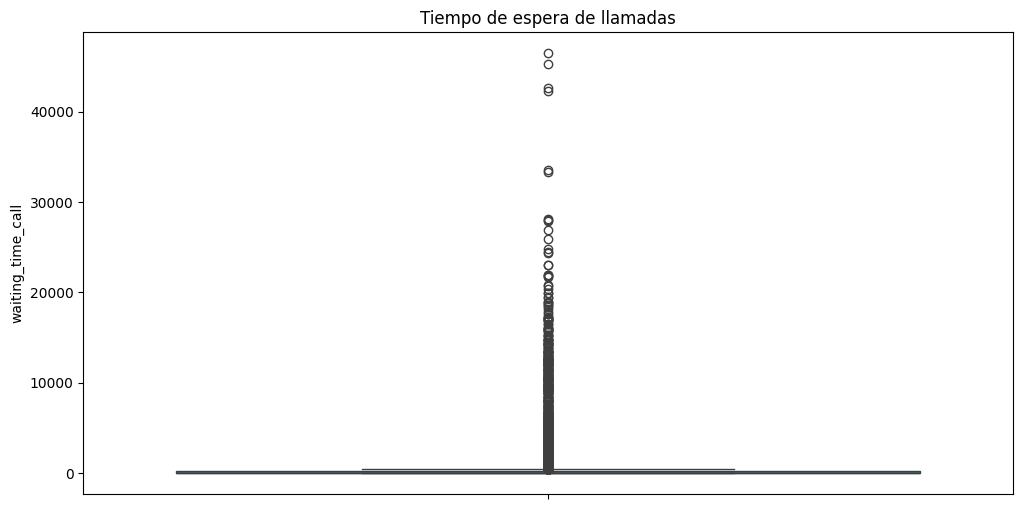

In [132]:
plt.figure(figsize=(12, 6))
plt.title('Tiempo de espera de llamadas')
sns.boxplot(y=df_tac_merged['waiting_time_call'])

<Axes: title={'center': 'Tiempo de espera de llamadas'}, ylabel='waiting_time_call'>

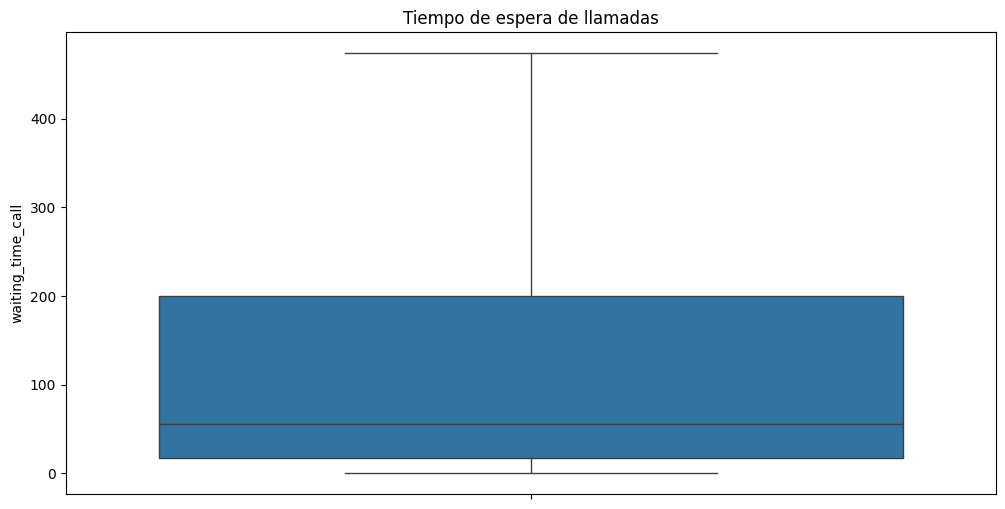

In [133]:
plt.figure(figsize=(12, 6))
plt.title('Tiempo de espera de llamadas')
sns.boxplot(y=df_tac_merged['waiting_time_call'], showfliers=False)

Con estos gráficosa de cajas observamos en primer lugar que existe variación en los datos y que también es considerable al cantidad de outliers con bastantes valroes atipicos, esto pude ser debido a distintos factores los cuales no tenemos conocimiento de sus causas pero sabemso que existen.

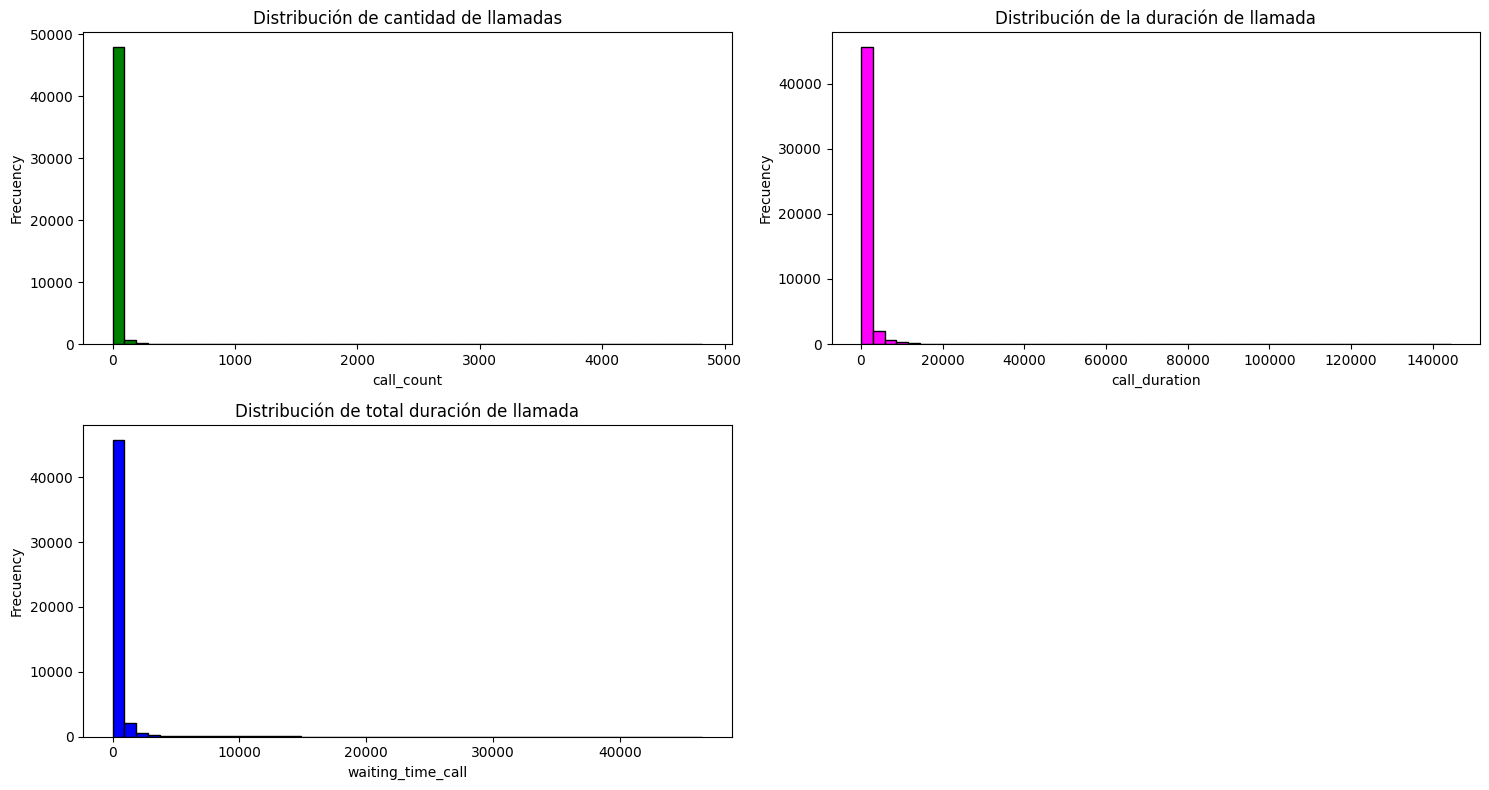

In [134]:
plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.hist(df_tac_merged['calls_count'], bins=50, color='green', edgecolor='black')
plt.title('Distribución de cantidad de llamadas')
plt.xlabel('call_count')
plt.ylabel('Frecuency')

plt.subplot(2, 2, 2)
plt.hist(df_tac_merged['call_duration'], bins=50, color='magenta', edgecolor='black')
plt.title('Distribución de la duración de llamada')
plt.xlabel('call_duration')
plt.ylabel('Frecuency')

plt.subplot(2, 2, 3)
plt.hist(df_tac_merged['waiting_time_call'], bins=50, color='blue', edgecolor='black')
plt.title('Distribución de total duración de llamada')
plt.xlabel('waiting_time_call')
plt.ylabel('Frecuency')

plt.tight_layout()
plt.show()

Los histogrmas nos esclarecen varias cosas:  
Los días tienen un número relativamente bajo de llamadas, ya que la frecuencia es más alta en los valores cercanos a cero.  
La mayoría de las llamadas tienen una duración corta, como se observa por la barra más alta al inicio del histograma.  
Los tiempos de espera suelen ser cortos pero aún así hay algunos que son exageradamente altos.

In [135]:
missed_calls = df_tac_merged[df_tac_merged['is_missed_call'] == True]
missed_calls = missed_calls['is_missed_call'].count()

missed_calls_false = df_tac_merged[df_tac_merged['is_missed_call'] == False]
missed_calls_false = missed_calls_false['is_missed_call'].count()

missed_total = df_tac_merged['is_missed_call'].count()
percentage_missed = (missed_calls / missed_total) * 100
percentage_not_missed = (missed_calls_false / missed_total) *100
print('El porcentaje de llamadas perdidas es = ', percentage_missed.round(2))
print('El porcentaje de llamadas contestadas es = ', percentage_not_missed.round(2))

El porcentaje de llamadas perdidas es =  43.78
El porcentaje de llamadas contestadas es =  56.22


Del total de llamadas observamso un dato interesante que mas del 40% de las llmadas son perdidas, lo cual hablando d enúmeros fríos es una cantidad muy alta.

# Concluciones EDA

Después de limpiar y enriquecer los data set en los pasos anteriores procedimos a hacer un pequeño análisis exploratorios de los datos donde encontramos lo siguiente:  
    
Que los registros están conformados entre el dos de agosto hasta el veinte y ocho de noviembre.  

El promedio de llamadas por día es de 1580 teniendo como0 máximo 2403 y un mínimo de 882.   

La mayor cantidad de las llamadas se hacen entre los días 18 y 26 de cada mes.  

También se observa que las llamadas salientes triplican a las llamadas entrantes, lo cual es entendible ya que los operadores un de sus funciones son las llamadas salientes.  

Las llamadas externas representan un 55% del total de las llamadas.  

Hay tres tipos de tarifas para los clientes donde los planes B y C tienen mas clientes que la tarifa A con más de 3,500 clientes.    
La mayoría de los días tienen una cantidad similar de llamadas.  

Las llamadas individuales varían considerablemente, probablemente por distintos factores, como problemas con los clientes o dificultades técnicas.  

Hay largos tiempos de espera, aunque no se conocen las razones pude ser por alta demanda o problemas técnicos también.  

Con los histogramas observamos de manera general que los valores se concentran en la parte inferior pero la existencia de valores atípico o fuera de rango están bastante presentes.  

El porcentaje de llamadas perdidas del total de las llamadas es de más del 40%.


# 4 IDENTIFICACION DE OPERADORES INEFICACES

## 4.1 Llamadas perdidas

,operator_id,date_month,calls_count
0,882680,9,3
1,882684,8,2
2,882684,9,2
3,882686,8,3
4,882686,9,1
...,...,...,...
318,959312,11,7
319,960620,11,1
320,964510,11,2
321,964666,11,3


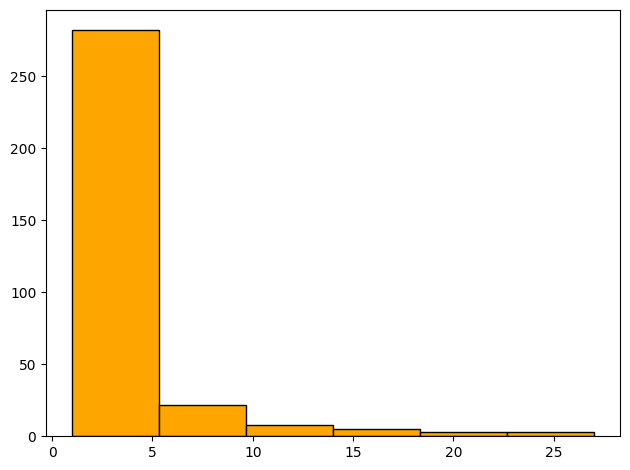

<Figure size 1500x600 with 0 Axes>

In [136]:
df_tac_merged['date_month'] = df_tac_merged['date'].dt.month
df_without_unknown = df_tac_merged[df_tac_merged['operator_id'] != 'unknown']
df_in_calls = df_without_unknown[df_without_unknown['direction'] == 'in']
df_missed_calls = df_in_calls[df_in_calls['is_missed_call'] == True]
df_missed_calls_group = df_missed_calls.groupby(['operator_id', 'date_month'])['calls_count'].sum().reset_index()
display(df_missed_calls_group)
plt.hist(df_missed_calls_group['calls_count'], bins=6, color='orange', edgecolor='black')
plt.tight_layout()
plt.figure(figsize=(15, 6))
plt.show()


Aquí filtramos le dat set para quitar aquellos usuarios que eran nulos y los rellenamos ocn unknown ya que el dejarlos no crearia un sesgo puesto que no sabemso que operador fue el que perdió la llamda; los usuarios en general tienen pocas llamadas perdidas por mes, para identificar operadores ineficaces nos concentraremos en los que tienen muchas.

In [137]:
df_missed_calls_group.describe()

,date_month,calls_count
count,323.000000,323.000000
mean,10.188854,2.866873
std,0.814236,3.834007
min,8.000000,1.000000
25%,10.000000,1.000000
50%,10.000000,1.000000
75%,11.000000,3.000000
max,11.000000,27.000000


In [138]:
q1_missed_calls = df_missed_calls_group['calls_count'].quantile(0.25)
q2_missed_calls = df_missed_calls_group['calls_count'].quantile(0.50)
q3_missed_calls = df_missed_calls_group['calls_count'].quantile(0.75)

interval = q3_missed_calls - q1_missed_calls
atipic_values = (q3_missed_calls + (1.5 * interval)).round()
print('Esta es la cantidad de llamdas perdidas que se consideran como el umbral: ', atipic_values)

Esta es la cantidad de llamdas perdidas que se consideran como el umbral:  6.0


In [139]:
ineffective_operators_missed_calls = df_missed_calls_group[df_missed_calls_group['calls_count'] > 6].drop_duplicates().reset_index(drop=True)
display(ineffective_operators_missed_calls['operator_id'].unique().tolist())
print('Son ', ineffective_operators_missed_calls['operator_id'].nunique(), 'operadores ineficaces')

['885876',
 '885890',
 '905104',
 '905862',
 '906392',
 '906412',
 '908960',
 '913938',
 '913942',
 '919204',
 '919554',
 '925922',
 '931458',
 '937956',
 '940588',
 '940622',
 '940630',
 '940652',
 '944216',
 '944218',
 '944220',
 '944222',
 '944226',
 '948286',
 '951508',
 '952948',
 '959312']

Son  27 operadores ineficaces


Para detectar que usuarios que  son ineficaces en uno de los 3 aspectos a considerar que son la llamadas perdidas lo que se realizó fue obtener los cuartiles a 25, 50 y 75 respectivamente luego calculamos el intervalo Inter cuartil con la formula q3-q1 para el intervalo y luego para obtener el valor umbral usamos q3 +(1.5 X (q3-q1) que serían datos atípicos, que para este parametros nos guiaremos por dichos valores ya que buscaremso fuera de lso extremos puesto que las llamdas perdidaas no se puden considerar todas por ineficacia del operador ya que hay factores externos como por ejemplo si se corta la llamada o si el operador no alcanza a contestar por estar atendiendo otra, así de esta manera obtuvimos 27 operadores ineficaces en el rubro de las llamadas perdidas

## 4.2 Tiempos de Espera

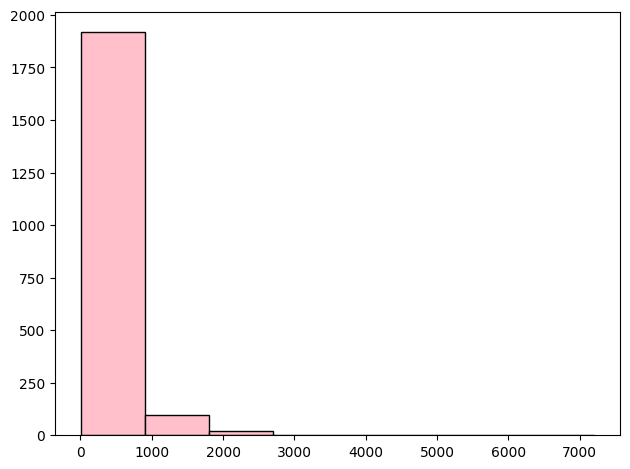

<Figure size 1500x600 with 0 Axes>

In [140]:
df_waiting_time = df_without_unknown[df_without_unknown['is_missed_call'] == False]
df_operator_wt = df_waiting_time.groupby(['operator_id', 'date_month']).agg(calls = ('waiting_time_call', 'count'),
    waiting_time = ('waiting_time_call', 'sum'),
    avg_waiting_time = ('waiting_time_call', 'mean')
).reset_index()
df_operator_wt

plt.hist(df_operator_wt['avg_waiting_time'], bins=8, color='pink', edgecolor='black')
plt.tight_layout()
plt.figure(figsize=(15, 6))
plt.show()

In [141]:
df_operator_wt.describe()

,date_month,calls,waiting_time,avg_waiting_time
count,2047.000000,2047.000000,2047.000000,2047.000000
mean,10.015144,13.403029,3258.395701,197.161504
std,0.933395,14.063856,14562.750472,458.515962
min,8.000000,1.000000,1.000000,1.000000
25%,9.000000,3.000000,76.000000,21.037037
50%,10.000000,8.000000,427.000000,45.000000
75%,11.000000,19.000000,2585.000000,141.346639
max,11.000000,76.000000,396317.000000,7205.763636


In [142]:
q1_waiting_time = df_operator_wt['avg_waiting_time'].quantile(0.25)
q2_waiting_time = df_operator_wt['avg_waiting_time'].quantile(0.50)
q3_waiting_time = df_operator_wt['avg_waiting_time'].quantile(0.75)

interval_wt = q3_waiting_time - q1_waiting_time
atipic_values_wt = (q3_waiting_time + (1.5 * interval_wt)).round()
 
print('Esta es la cantidad de segundos que se consideran como el umbral para el tiempo de esepra de las llamadas: ', atipic_values_wt)

Esta es la cantidad de segundos que se consideran como el umbral para el tiempo de esepra de las llamadas:  322.0


In [143]:
ineffective_operators_waiting_time = df_operator_wt[df_operator_wt['avg_waiting_time'] > 322].drop_duplicates().reset_index(drop=True)
display(ineffective_operators_waiting_time['operator_id'].unique().tolist())
print('Son ', ineffective_operators_waiting_time['operator_id'].nunique(), 'operadores ineficaces')

['879898',
 '882686',
 '882690',
 '884478',
 '884946',
 '885876',
 '885890',
 '887282',
 '892028',
 '893674',
 '893804',
 '896382',
 '896386',
 '899790',
 '899972',
 '900180',
 '901992',
 '902510',
 '902742',
 '902744',
 '902746',
 '902748',
 '902774',
 '902776',
 '902778',
 '902782',
 '904016',
 '905432',
 '906070',
 '906076',
 '906404',
 '906406',
 '906866',
 '907174',
 '908640',
 '909502',
 '910530',
 '913938',
 '913942',
 '917234',
 '918986',
 '919126',
 '919162',
 '919164',
 '919166',
 '919188',
 '919192',
 '919194',
 '919196',
 '919198',
 '919200',
 '919202',
 '919204',
 '919206',
 '919302',
 '919306',
 '919310',
 '919314',
 '919318',
 '919362',
 '919364',
 '919370',
 '919372',
 '919374',
 '919376',
 '919378',
 '919382',
 '919390',
 '919456',
 '919464',
 '919476',
 '919482',
 '919490',
 '919504',
 '919552',
 '919554',
 '919790',
 '919794',
 '919906',
 '919910',
 '920414',
 '920416',
 '921318',
 '921574',
 '921584',
 '921592',
 '921594',
 '921596',
 '921818',
 '922710',
 '923666',

Son  171 operadores ineficaces


Con el mismo principio que obtuvimos los operarios ineficaces en el paso anterior ahora tenemos que 171 operadores dentro de la condición de tiempo de espera caen en el rango de operadores ineficaces.

In [144]:
q3_waiting_time.round(1)

ineffective_operators_waiting_time_over141 = df_operator_wt[df_operator_wt['avg_waiting_time'] > 141].drop_duplicates().reset_index(drop=True)
display(ineffective_operators_waiting_time_over141)
print('Son ', ineffective_operators_waiting_time_over141['operator_id'].nunique(), 'operadores ineficaces')

,operator_id,date_month,calls,waiting_time,avg_waiting_time
0,879898,8,30,10060,335.333333
1,879898,9,37,15139,409.162162
2,879898,10,43,21097,490.627907
3,879898,11,28,7867,280.964286
4,882684,8,32,5001,156.281250
...,...,...,...,...,...
507,968338,11,13,2426,186.615385
508,969272,11,18,3824,212.444444
509,971102,11,4,1352,338.000000
510,972410,11,2,456,228.000000


Son  306 operadores ineficaces


A diferencia de las llamda sperdidas aquí el umbral para valores atípicos esta en lso 322 segundos que es mas de 5 minutos de espera, lo cual es demasiado investigando en internet encontre que un tiempo razonable ronda entre lso dos minutos por lo qu e entonces tomaos q3 que es de 144 segundos que son 2.4 minutos para CallMeMaybe y si filtramos con ese dato ahora son 306 operadores. 

## 4.3 Llamadas realizadas por lo operarios llamadas salientes, un número reducido de ellas también será un signo de ineficacia

,operator_id,date_day,calls_count
0,880240,2,1
1,880240,4,2
2,880240,6,2
3,880240,8,1
4,880240,9,4
...,...,...,...
3430,970486,26,4
3431,972408,27,6
3432,972410,27,25
3433,972410,28,52


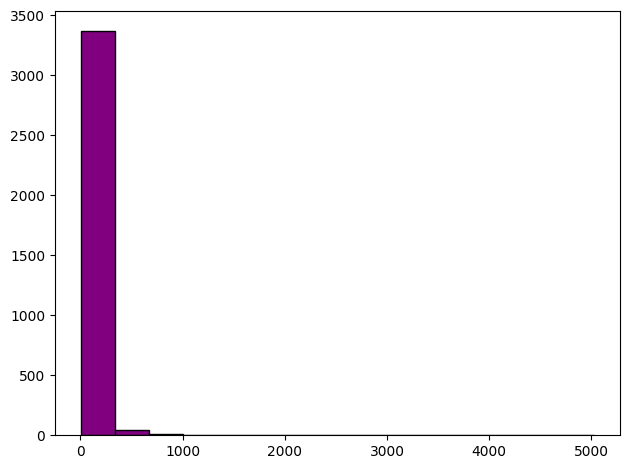

<Figure size 1500x600 with 0 Axes>

In [145]:
df_operators_calls_in = df_in_calls['operator_id'].unique()

df_operators_calls_out = df_without_unknown[(df_without_unknown['direction'] == 'out')]
df_operators_calls_out = df_operators_calls_out[~df_operators_calls_out['operator_id'].isin(df_operators_calls_in)]
#df_operators_calls_out

df_operators_calls_out_1 = df_operators_calls_out.groupby(['operator_id', 'date_day'])['calls_count'].sum().reset_index()
df_operators_calls_out_1.sort_values('calls_count')
display(df_operators_calls_out_1)

plt.hist(df_operators_calls_out_1['calls_count'], bins=15, color='purple', edgecolor='black')
plt.tight_layout()
plt.figure(figsize=(15, 6))
plt.show()

In [146]:
df_operators_calls_out_1.describe()

,date_day,calls_count
count,3435.000000,3435.000000
mean,16.128384,76.840175
std,8.680815,157.983914
min,1.000000,1.000000
25%,9.000000,6.000000
50%,16.000000,32.000000
75%,24.000000,111.000000
max,31.000000,5029.000000


In [147]:
q1_calls_out = df_operators_calls_out_1['calls_count'].quantile(0.25)
q2_calls_out = df_operators_calls_out_1['calls_count'].quantile(0.50)
q3_calls_out = df_operators_calls_out_1['calls_count'].quantile(0.75)

print('Este es el q1 de las llamadas salientes: ',q1_calls_out)

Este es el q1 de las llamadas salientes:  6.0


A diferencia de los parametros anteriores donde q3 fue nuestra referencia, umbral o límite para esta métrica sera lo contrario; siendo el q1 nuestra referencia ya que buscamso números reducidos de llamdas por parte de los operadores. Así que tomamos q1 que es igual a 6 llamdas como es elímite inferior.

In [148]:
ineffective_operators_calls_out = df_operators_calls_out_1[df_operators_calls_out_1['calls_count'] < 6].drop_duplicates().reset_index(drop=True)
display(ineffective_operators_calls_out['operator_id'].unique().tolist())
print('Son ', ineffective_operators_calls_out['operator_id'].nunique(), 'operadores ineficaces')

['880240',
 '881278',
 '883018',
 '883898',
 '884402',
 '884406',
 '885682',
 '887280',
 '890232',
 '890234',
 '890420',
 '890422',
 '891152',
 '891154',
 '891156',
 '891158',
 '891160',
 '891162',
 '891166',
 '891170',
 '891192',
 '891250',
 '891252',
 '891746',
 '891976',
 '892028',
 '892800',
 '893674',
 '893700',
 '894226',
 '896008',
 '896384',
 '896390',
 '897894',
 '898434',
 '898902',
 '899076',
 '899788',
 '899790',
 '899964',
 '899968',
 '899972',
 '902774',
 '902778',
 '905308',
 '905470',
 '905480',
 '905570',
 '905840',
 '906866',
 '907180',
 '907442',
 '907998',
 '908718',
 '909308',
 '909502',
 '909910',
 '910520',
 '910524',
 '910532',
 '910902',
 '910926',
 '914036',
 '914052',
 '914238',
 '914240',
 '914266',
 '914272',
 '914338',
 '914348',
 '914626',
 '914816',
 '915358',
 '915360',
 '915504',
 '915558',
 '916596',
 '917446',
 '917890',
 '918390',
 '918452',
 '919126',
 '919128',
 '919162',
 '919188',
 '919192',
 '919194',
 '919198',
 '919302',
 '919306',
 '919310',

Son  238 operadores ineficaces


## 4.4 Identificación de operadores ineficaces

In [149]:
df_ineffective_operators = pd.DataFrame(df_without_unknown['operator_id'].unique(), columns=['operator_id'])

df_ineffective_operators['missed_calls'] = df_ineffective_operators['operator_id'].isin(
    ineffective_operators_missed_calls['operator_id']).astype(int)

df_ineffective_operators['waiting_time'] = df_ineffective_operators['operator_id'].isin(
    ineffective_operators_waiting_time['operator_id']).astype(int)

df_ineffective_operators['calls_out'] = df_ineffective_operators['operator_id'].isin(
    ineffective_operators_calls_out['operator_id']).astype(int)


df_ineffective_operators['total_points'] = (df_ineffective_operators['missed_calls'] + df_ineffective_operators['waiting_time'] + 
    df_ineffective_operators['calls_out'])

display(df_ineffective_operators)

,operator_id,missed_calls,waiting_time,calls_out,total_points
0,880022,0,0,0,0
1,880020,0,0,0,0
2,881278,0,0,1,1
3,880028,0,0,0,0
4,880026,0,0,0,0
...,...,...,...,...,...
1087,958394,0,0,0,0
1088,952914,0,0,0,0
1089,952916,0,0,0,0
1090,959118,0,0,1,1


Al terminar de buscar aquellos operadores ineficaces en tres distintos parametros: llamadas perdidas, tiempo de espera y llamadas realizadas ahora conformamos un nuevo dataset en el cual incluimos a todos los operadores quitando aquellos valores "unknown", con las siguientes columnas: missed_calls, waiting_time calls_out y total_points con al intención de que el 1 indica si aparecen en lso datasets de operadores ineficaces hechos anteriormente y uan columna final donde encontraremos la suma de esos 1 así podremos esclarecer cuales son los operadores ineficaces.

In [150]:
print('Estas son las puntuaciones obtenidas: ', df_ineffective_operators['total_points'].unique())

Estas son las puntuaciones obtenidas:  [0 1 2]


In [151]:
print(' Cantidad de usuarios únicos: ', df_without_unknown['operator_id'].nunique())
print()
print('Son la cantidad de usuarios con un punto ', 
      len(df_ineffective_operators[df_ineffective_operators['total_points'] == 1]))
print()
print('Son la cantidad de usuarios con un punto ', 
      len(df_ineffective_operators[df_ineffective_operators['total_points'] == 2]))

 Cantidad de usuarios únicos:  1092

Son la cantidad de usuarios con un punto  336

Son la cantidad de usuarios con un punto  50


In [152]:
print('Lista de operadores ineficaces:')
print()
df_ineffective_operators_1 = df_ineffective_operators[df_ineffective_operators['total_points'] != 0]
print(df_ineffective_operators_1['operator_id'].tolist())

Lista de operadores ineficaces:

['881278', '882686', '902510', '882690', '939470', '939476', '879898', '880240', '907442', '960950', '887280', '887282', '907174', '906866', '959312', '884402', '884406', '883018', '883898', '885682', '884946', '890234', '890232', '892028', '893674', '891192', '897894', '910902', '910926', '923250', '939236', '947480', '930524', '884478', '908960', '885890', '885876', '925922', '892800', '891166', '891152', '891154', '891158', '890420', '890422', '891170', '891162', '891160', '891156', '891746', '916596', '917234', '919418', '932050', '932088', '932502', '932500', '950444', '954642', '965328', '891250', '891252', '894226', '891976', '893804', '900180', '955820', '893700', '917890', '896008', '906392', '906404', '906406', '906412', '928282', '928284', '955094', '955090', '955082', '955068', '955086', '896382', '896390', '896386', '896384', '914626', '905432', '909502', '914036', '898902', '899788', '899972', '899968', '899790', '899964', '898434', '89907

 Aquí enocntramos que tenemos 1092 operadores d elos cuales 50 de ellos se pueden etiquetar como ineficaces pero hay 336 operadaores que caen dentro de uno d elos tres parametros de ineficacia 

# 5 PRUEBAS DE HIPOTESIS

## 5.1 Pruebas de Hipótesis para llamdas perdidas

In [153]:
df_effective_operators_missed_calls = df_missed_calls_group[~df_missed_calls_group['operator_id'].isin(ineffective_operators_missed_calls['operator_id'])].reset_index(drop=True)
df_ineffective_operators_missed_calls = df_missed_calls_group[df_missed_calls_group['operator_id'].isin(ineffective_operators_missed_calls['operator_id'])].reset_index(drop=True)

group_a = df_effective_operators_missed_calls['calls_count']
group_b = df_ineffective_operators_missed_calls['calls_count']

variance_proof_1 = st.levene(group_a, group_b)
print('Resultado de pruebas de varianza:', variance_proof_1)

alpha = 0.05
results_1 = st.ttest_ind(group_a, group_b, equal_var=False)
print('Valor p:', results_1.pvalue)

if results_1.pvalue < alpha:
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

Resultado de pruebas de varianza: LeveneResult(statistic=np.float64(149.47986032414832), pvalue=np.float64(1.7607936287998196e-28))
Valor p: 2.1098811446105615e-11
Rechazamos la hipótesis nula


Se propuso realizar una prueba de hipótesis de dos colas sobre la igualdad de las medias de dos poblaciones en este caso los operadores considerados eficaces y por otro lado los ineficaces donde:  
    
H0 = Las llamdas perdidas promedio de los operadores eficaces son iguales a las de los operadores ineficaces  
    
H1 = Las llamdas perdidas promedio de los operadores eficaces NO son iguales a las de los operadores ineficaces  

Se encontró que si hay diferencia significativa estadística entre operadores eficaces e ineficaces.

## 5.2 Pruebas de Hipótesis para la espera de llamadas
H0 = Los tiempos de espera promedio de los operadores eficaces son iguales a los de los operadores ineficaces  
H1 =Los tiempos de espera promedio de los operadores eficaces NO son iguales a los de los operadores ineficaces  

In [154]:
df_effective_operators_waiting_time = df_operator_wt[~df_operator_wt['operator_id'].isin(ineffective_operators_waiting_time_over141['operator_id'])].reset_index(drop=True)
df_ineffective_operators_waiting_time =df_operator_wt[df_operator_wt['operator_id'].isin(ineffective_operators_waiting_time_over141['operator_id'])].reset_index(drop=True)

group_a_1 = df_effective_operators_waiting_time['waiting_time']
group_b_1 = df_ineffective_operators_waiting_time['waiting_time']

variance_proof_2 = st.levene(group_a_1, group_b_1)
print('Resultado de pruebas de varianza:', variance_proof_2)

alpha = 0.05
results_2 = st.ttest_ind(group_a_1, group_b_1, equal_var=False)
print('Valor p:', results_2.pvalue)

if results_2.pvalue < alpha:
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

Resultado de pruebas de varianza: LeveneResult(statistic=np.float64(105.9778581470784), pvalue=np.float64(2.8834491443636093e-24))
Valor p: 3.28245213699382e-17
Rechazamos la hipótesis nula


Siguiendo elmismo principio de las pruebas nateriores ahora las realizamos para el parametro de tiempo de espera y también rechazamos la hipótesisi nula

## 5.3 Pruebas de Hipótesis para las llamadas realizadas por los operadores
H0 = La cantidad de llamdas salientes promedio por usuario de los operadores eficaces son iguales a los de los operadores ineficaces  
H1 = La cantidad de llamdas salientes promedio por usuario de los operadores eficaces NO son iguales a los de los operadores ineficaces  

In [155]:
df_effective_operators_calls_out = df_operators_calls_out_1[~df_operators_calls_out_1['operator_id'].isin(ineffective_operators_calls_out['operator_id'])].reset_index(drop=True)
df_ineffective_operators_calls_out = df_operators_calls_out_1[df_operators_calls_out_1['operator_id'].isin(ineffective_operators_calls_out['operator_id'])].reset_index(drop=True)

group_a_2 = df_effective_operators_calls_out['calls_count']
group_b_2 = df_ineffective_operators_calls_out['calls_count']

variance_proof_3 = st.levene(group_a_2, group_b_2)
print('Resultado de pruebas de varianza:', variance_proof_3)

alpha = 0.05
results_3 = st.ttest_ind(group_a_2, group_b_2, equal_var=False)
print('Valor p:', results_2.pvalue)

if results_3.pvalue < alpha:
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

Resultado de pruebas de varianza: LeveneResult(statistic=np.float64(65.35938493361645), pvalue=np.float64(8.565406979979381e-16))
Valor p: 3.28245213699382e-17
Rechazamos la hipótesis nula


 La diferencia significativa entre el promedio de la cantidad de llamadas salientes existe ya que se rechazó la hipótesis nula.

# 6 CONCLUSIONES Y RECOMENDACIONES

Después de terminar el análisis para la empresa de telefonía virtual CallMeBaby que consistió en procesamiento, limpieza y enriquecimiento de datos, como parte inicial, donde se eliminaron aquellas filas completas duplicadas ya que eran 4900 filas de 53,902 lo cual es más de un 9% y podría afectar o sesgar el análisis, después nos ocupamos de los valores nulos donde en la columna operator_id aparecen un total de 7,456 lo cual también es un porcentaje alto del total de entradas en el dataset pero casi todos están relacionados con el valor True de la columna is_missed_call lo cual nos indica que son llamadas perdidas y por lo tanto es entendible que no tengan un operador asignado y lo confirmamos con la función len() en la columna call_duration debe tener en su mayoría valor 0; pero a diferencia de los valores duplicados no los eliminamos sino que los rellenamos con la palabra unknown. Por último, los valores nulos de la columna internal encontramos solo 110 valores que este si es un porcentaje pequeño apenas del 0.22% por lo que se podrían eliminar esas filas o también añadir 55 y 55 a true y false que fue lo que se realizó ya que 110 valores es un porcentaje que no llega ni al 0.5% del dataset. 

Después de limpiar y enriquecer los data set en los pasos anteriores procedimos a hacer un pequeño análisis exploratorios de los datos donde encontramos lo siguiente:

Que los registros están conformados entre el dos de agosto hasta el veinte y ocho de noviembre. 

El promedio de llamadas por día es de 1580 teniendo como0 máximo 2403 y un mínimo de 882.  

La mayor cantidad de las llamadas se hacen entre los días 18 y 26 de cada mes.    

También se observa que las llamadas salientes triplican a las llamadas entrantes, lo cual es entendible ya que los operadores un de sus funciones son las llamadas salientes.   

Las llamadas externas representan un 55% del total de las llamadas.    

Hay tres tipos de tarifas para los clientes donde los planes B y C tienen más clientes que la tarifa A con más de 3,500 clientes.      
La mayoría de los días tienen una cantidad similar de llamadas. 

Las llamadas individuales varían considerablemente, probablemente por distintos factores, como problemas con los clientes o dificultades técnicas.    
Hay largos tiempos de espera, aunque no se conocen las razones pude ser por alta demanda o problemas técnicos también. 

Con los histogramas observamos de manera general que los valores se concentran en la parte inferior pero la existencia de valores atípico o fuera de rango están bastante presentes. 

El porcentaje de llamadas perdidas del total de las llamadas es de más del 40%.  

Para identificar aquellos operadores ineficaces se utilizó mediante la obtención de cuartiles para establecer limites o umbrales, tanto para las llamadas perdidas como el tiempo de espera el Q3 y para las llamadas realizadas Q1.  

En el caso de el tiempo de espera se tomó como referencia un tiempo de dos minutos, este sacado de una pequeña investigación en cuanto al promedio de espera para un callcenter o una empresa de telefonía. 

Una vez deyectados los operadores ineficaces en cada parámetro se hizo un atabla con los operadores y tres columnas referentes a los parámetros donde se concedía un 1 si es que son ineficaces en ese rubro y una ultima columna con el total de puntos para determinar si son o no ineficaces. 

También se realizaron pruebas de hipótesis donde en los tres casos se rechazó la hipótesis nula  tanto para comprobar si el promedio de llamadas perdidas, el tiempo promedio de espera y la cantidad promedio de llamadas realizadas por usuario son iguales o hay diferencias significativas entre ellas el valor Alpha utilizado para dichas pruebas fue de 0.05 puesto que se busca un rigor moderado y equilibrado en las pruebas ya que no estamos en temas médicos o de ingeniería que implica tener mayor rigor.  

Que recomendaciones le daríamos a CallMeMaybe después de finalizar el análisis:  

1)	Hay 50 operadores totalmente inoperantes
  
2)	Necesita prestar atención a la cantidad de llamadas realizadas por sus operadores

3)	Mejorar su capacitación en cuanto a los tiempos de espera

4)	El parámetro de llamadas perdidas parece ser un tema que esta controlado.
 

Link tableau: https://public.tableau.com/app/profile/alvaro.bonilla/viz/PROYECTOEMPRESADETELEFONIACallMeMaybe/DashboardCallMeMaybe?publish=yes 